**Build a vol surface using the bisection method for calculating IV**

In [ ]:
import pandas as pd 

import sys
sys.path.append('../')
from modules.implied_volatility import bisection
from modules.plots import *
from modules.utils import *
from modules.rates import merge_rates

Defaulting to user installation because normal site-packages is not writeable
  Using cached pandas_datareader-0.11.1-py3-none-any.whl.metadata (3.8 kB)
Using cached pandas_datareader-0.11.1-py3-none-any.whl (65 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\wfpin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Read in our data + add rates
raw_options = pd.read_csv('../data/spy_surface_raw.csv')
raw_options = merge_rates(raw_options)
raw_options.head()

,date,spot,ticker,strike,expiry,dte,years_to_expiry,moneyness,target_moneyness,target_dte,option_type,close,volume,r
0,2026-01-15,688.580688,O:SPY270115C00690000,690.0,2027-01-15,365,0.999316,1.002061,1.0,365,call,59.60,84,0.0354
1,2026-01-15,688.580688,O:SPY270115P00690000,690.0,2027-01-15,365,0.999316,1.002061,1.0,365,put,39.46,881,0.0354
2,2026-01-15,688.580688,O:SPY260213P00620000,620.0,2026-02-13,29,0.079398,0.900403,0.9,30,put,0.93,115,0.0375
3,2026-01-15,688.580688,O:SPY260213C00689000,689.0,2026-02-13,29,0.079398,1.000609,1.0,30,call,13.12,257,0.0375
4,2026-01-15,688.580688,O:SPY260213P00689000,689.0,2026-02-13,29,0.079398,1.000609,1.0,30,put,7.96,131,0.0375


In [5]:
market_price = raw_options['close'].values
S = raw_options['spot'].values
K = raw_options['strike'].values
T = raw_options['years_to_expiry'].values
r = raw_options['r']
option_type = raw_options['option_type'].values

raw_options['IV'] = bisection(
    market_price=market_price,
    S=S,
    T=T,
    r=r,
    K=K,
    option_type=option_type
)

otm_options = select_otm(raw_options)

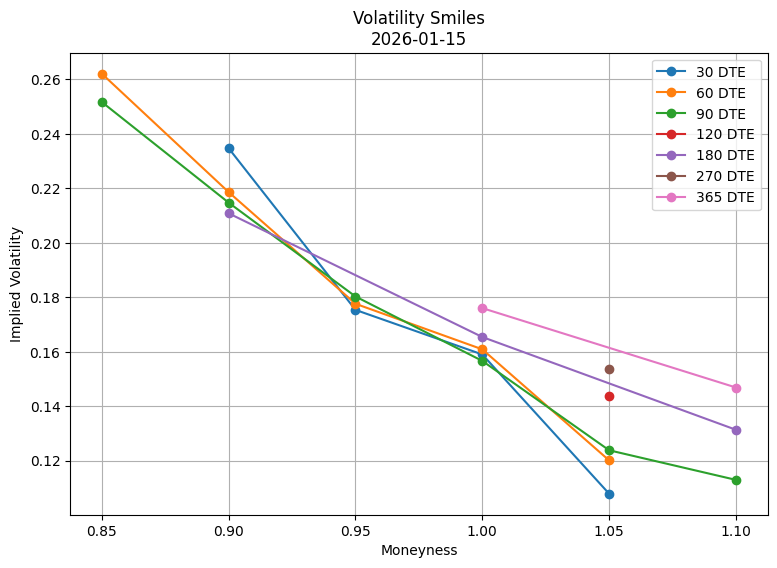

In [6]:
plot_skews(otm_options, '2026-01-15')

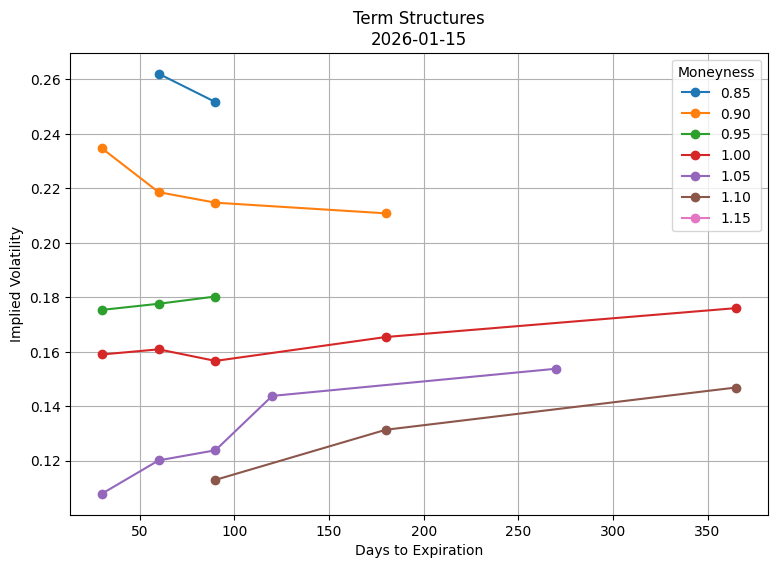

In [7]:
plot_term_structures(otm_options, '2026-01-15')

c:\Users\wfpin\Desktop\Projects\kf-vol-surface\notebooks\..\modules\utils.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['log_moneyness'] = np.log(df['target_moneyness'])


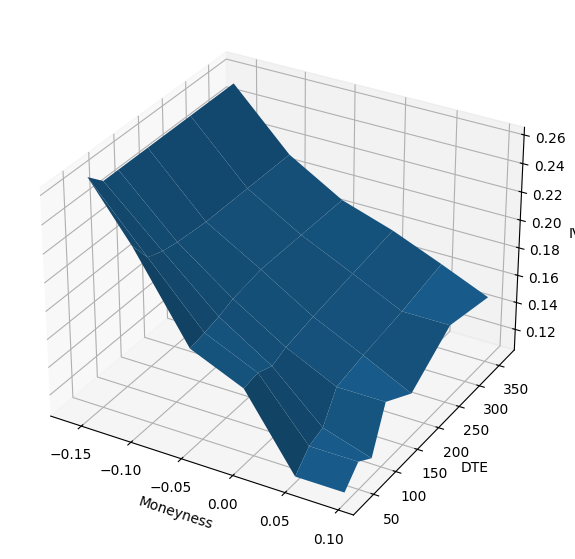

In [8]:
surface = create_surface(otm_options, '2026-01-15')
surface = interpolate_surface(surface)
plot_surface(surface)